# K-Means и K-Means++

**В этом ноутбуке посмотрим:**
1. Как K-Means ищет центры кластеров
2. Random init vs K-Means++
3. Выбор количества кластеров (Elbow + Silhouette)
4. Метрики качества: Inertia, Silhouette, Davies-Bouldin, Calinski-Harabasz

## 1. Импорты и данные

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)

plt.rcParams['figure.figsize'] = (8, 5)
np.random.seed(42)

##2. Сгенерируем датасет с 4 кластерами

In [28]:
X, y_true = make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=0.8,
    random_state=42,
)

df = pd.DataFrame(X, columns=['x1', 'x2'])
df.head()

,x1,x2
0,-7.918909,6.760982
1,-9.037137,-6.923545
2,6.391721,1.326531
3,-2.822884,7.843474
4,-5.918656,-7.206570


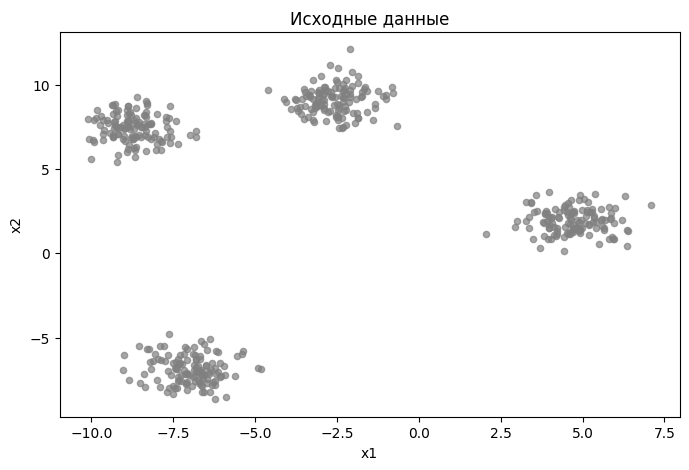

In [29]:
plt.scatter(X[:, 0], X[:, 1], s=20, c='gray', alpha=0.7)
plt.title('Исходные данные')
plt.xlabel('x1'); plt.ylabel('x2')
plt.show()

## 3. Как K-Means ищет центры кластеров

Алгоритм:
1. Выбираем `k` начальных центров.
2. Каждую точку относим к ближайшему центру.
3. Пересчитываем центры как среднее точек кластера.
4. Повторяем 2–3, пока центры не перестанут двигаться.

Покажем процесс по шагам через `max_iter`.

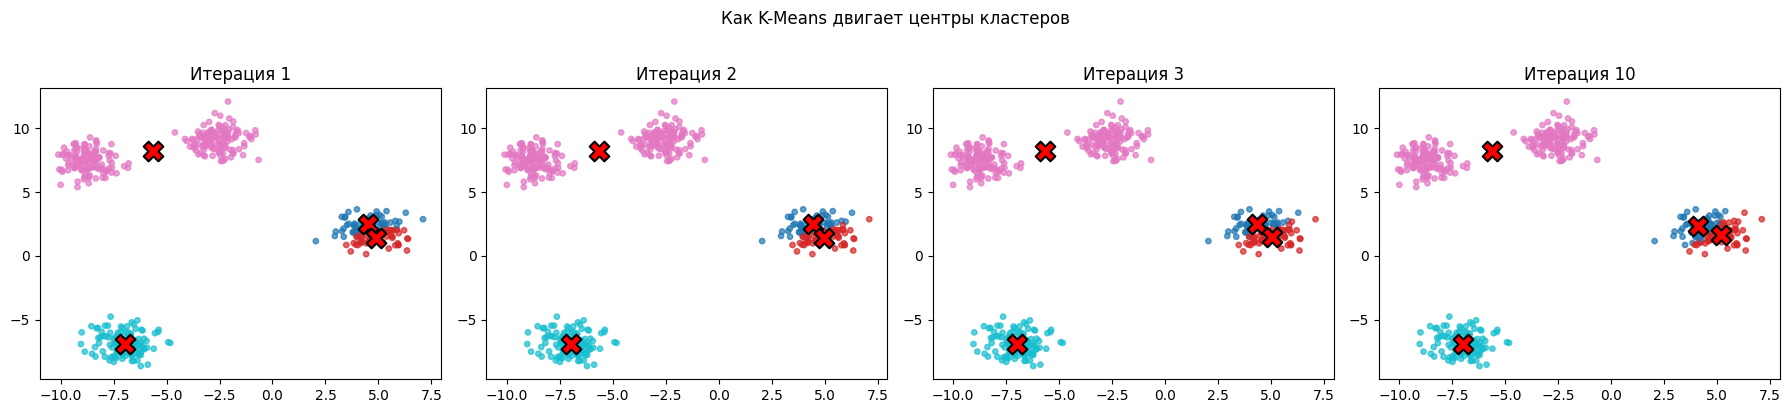

In [30]:
iterations_to_show = [1, 2, 3, 10]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, n_iter in zip(axes, iterations_to_show):
    km = KMeans(
        n_clusters=4,
        init='random',
        n_init=1,
        max_iter=n_iter,
        random_state=1,
    )
    labels = km.fit_predict(X)

    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=15, alpha=0.7)
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
               c='red', marker='X', s=200, edgecolors='black', linewidths=1.5)
    ax.set_title(f'Итерация {n_iter}')

plt.suptitle('Как K-Means двигает центры кластеров', y=1.02)
plt.tight_layout()
plt.show()

Видно, что центры (красные крестики) постепенно «расходятся» по реальным кластерам.

## 4. Random init vs K-Means++

- **random** — начальные центры берутся случайно. Можно «застрять» в плохом локальном минимуме.
- **k-means++** — центры выбираются так, чтобы они были максимально далеко друг от друга. Обычно сходится быстрее и к лучшему результату.

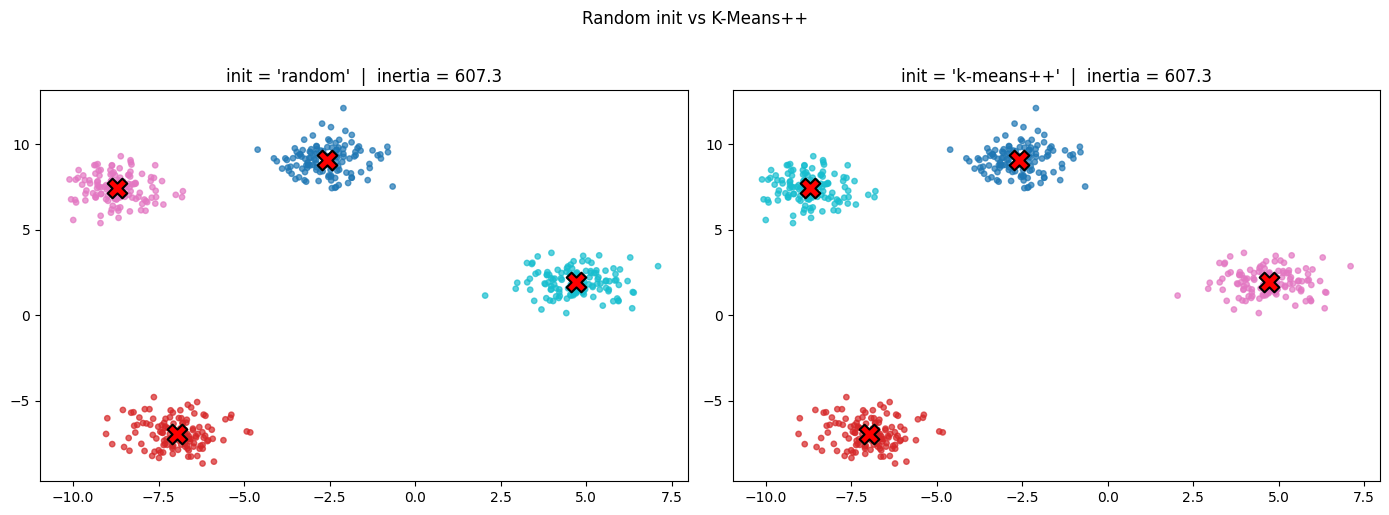

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, init_method in zip(axes, ['random', 'k-means++']):
    km = KMeans(n_clusters=4, init=init_method, n_init=1, random_state=3)
    labels = km.fit_predict(X)

    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=15, alpha=0.7)
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
               c='red', marker='X', s=200, edgecolors='black', linewidths=1.5)
    ax.set_title(f"init = '{init_method}'  |  inertia = {km.inertia_:.1f}")

plt.suptitle('Random init vs K-Means++', y=1.02)
plt.tight_layout()
plt.show()

In [32]:
results = []
for seed in range(30):
    for init_method in ['random', 'k-means++']:
        km = KMeans(n_clusters=4, init=init_method, n_init=1, random_state=seed)
        km.fit(X)
        results.append({'init': init_method, 'inertia': km.inertia_})

res_df = pd.DataFrame(results)
res_df.groupby('init')['inertia'].agg(['mean', 'std', 'min', 'max']).round(2)

,mean,std,min,max
init,,,,
k-means++,607.29,0.00,607.29,607.29
random,1954.98,2562.42,607.29,13957.77


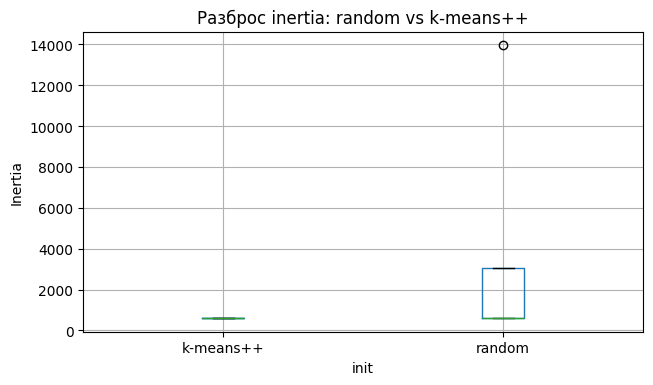

In [33]:
res_df.boxplot(column='inertia', by='init', figsize=(7, 4))
plt.title('Разброс inertia: random vs k-means++')
plt.suptitle('')
plt.ylabel('Inertia')
plt.show()

K-Means++ даёт стабильнее и в среднем меньшие значения inertia.

## 5. Как выбрать количество кластеров

### 5.1. Elbow method (локоть)
Строим зависимость inertia от `k`. Ищем «локоть» — точку, после которой улучшение замедляется.

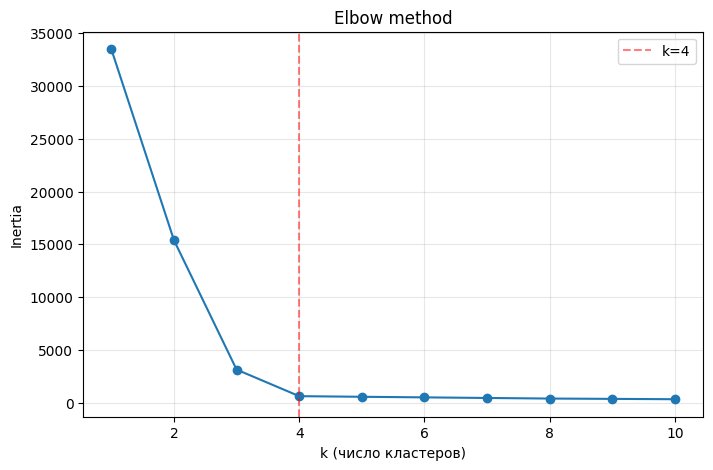

In [34]:
k_range = range(1, 11)
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)

plt.plot(list(k_range), inertias, 'o-')
plt.axvline(4, color='red', linestyle='--', alpha=0.5, label='k=4')
plt.xlabel('k (число кластеров)')
plt.ylabel('Inertia')
plt.title('Elbow method')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### **5.2**. Silhouette score при разном k
Чем выше silhouette, тем лучше. Хороший `k` — где значение максимально.

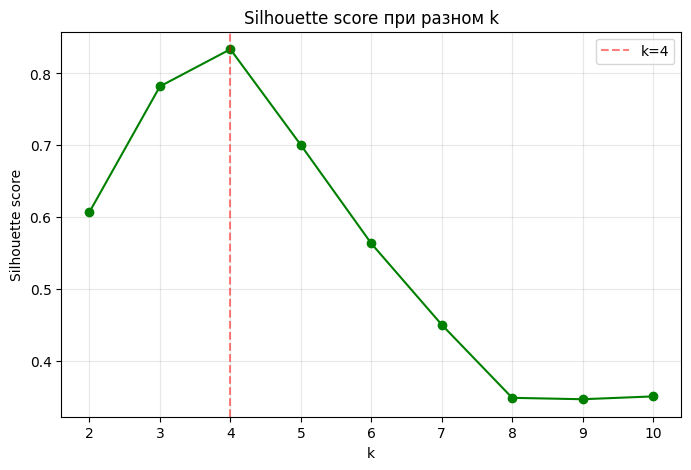

In [35]:
k_range = range(2, 11)
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X)
    sil_scores.append(silhouette_score(X, labels))

plt.plot(list(k_range), sil_scores, 'o-', color='green')
plt.axvline(4, color='red', linestyle='--', alpha=0.5, label='k=4')
plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.title('Silhouette score при разном k')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 6. Метрики качества кластеризации

In [36]:
metrics = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X)
    metrics.append({
        'k': k,
        'Inertia': km.inertia_,
        'Silhouette': silhouette_score(X, labels),
        'Davies-Bouldin': davies_bouldin_score(X, labels),
        'Calinski-Harabasz': calinski_harabasz_score(X, labels),
    })

metrics_df = pd.DataFrame(metrics).set_index('k')
metrics_df.round(3)

,Inertia,Silhouette,Davies-Bouldin,Calinski-Harabasz
k,,,,
2,15385.936,0.607,0.500,585.785
3,3124.987,0.782,0.328,2414.162
4,607.290,0.834,0.234,8950.625
5,547.809,0.700,0.595,7440.567
6,492.360,0.564,0.860,6620.311
7,435.883,0.451,1.016,6231.222
8,380.463,0.349,1.114,6115.879
9,350.147,0.347,1.059,5811.197
10,317.249,0.351,0.995,5691.886


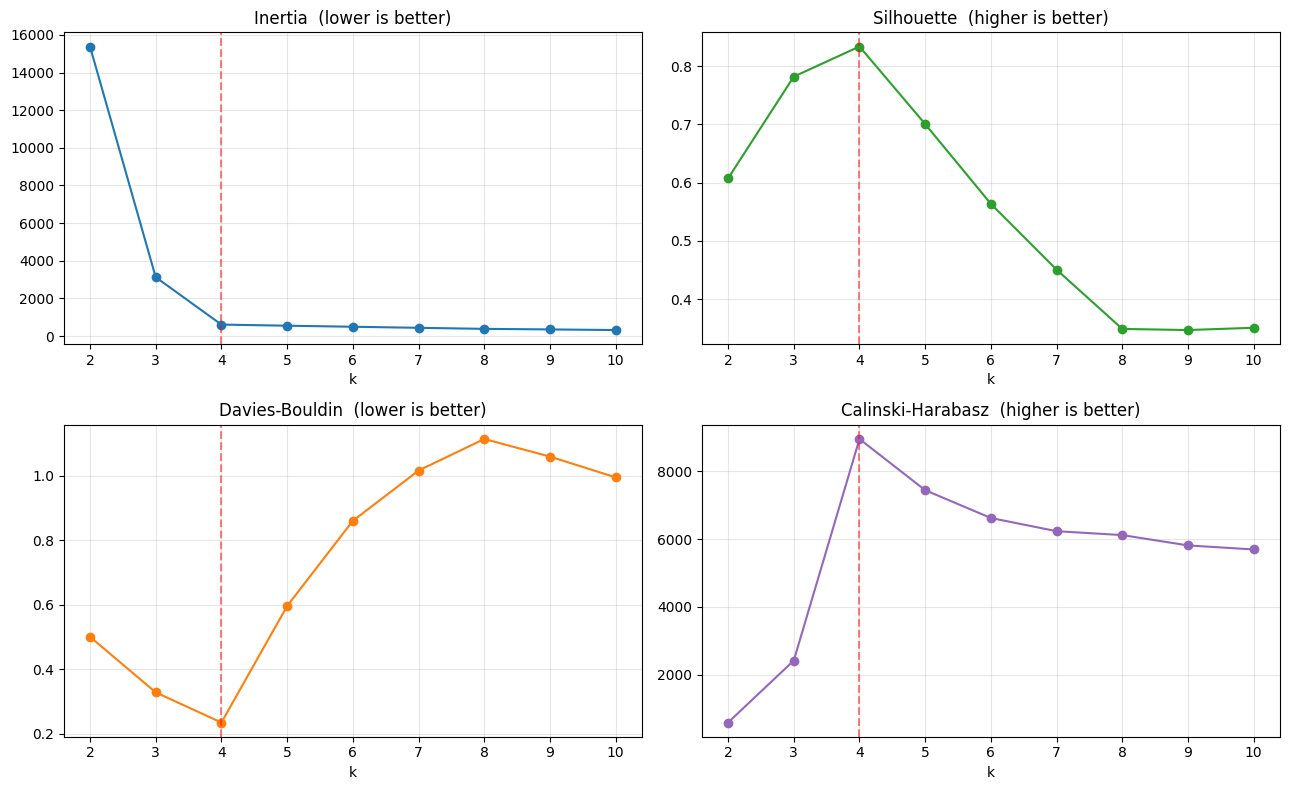

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

configs = [
    ('Inertia', 'lower is better', 'tab:blue'),
    ('Silhouette', 'higher is better', 'tab:green'),
    ('Davies-Bouldin', 'lower is better', 'tab:orange'),
    ('Calinski-Harabasz', 'higher is better', 'tab:purple'),
]

for ax, (col, note, color) in zip(axes.flatten(), configs):
    ax.plot(metrics_df.index, metrics_df[col], 'o-', color=color)
    ax.axvline(4, color='red', linestyle='--', alpha=0.5)
    ax.set_title(f'{col}  ({note})')
    ax.set_xlabel('k')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Финальная модель с найденным k=4

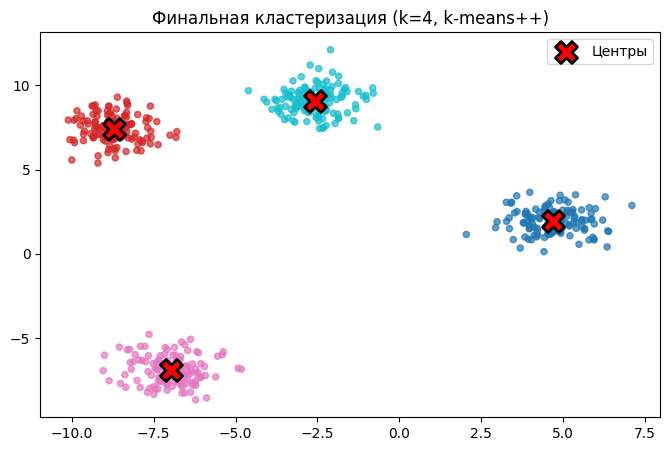

Inertia:           607.29
Silhouette:        0.834
Davies-Bouldin:    0.234
Calinski-Harabasz: 8950.6


In [38]:
final_km = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
final_labels = final_km.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=final_labels, cmap='tab10', s=20, alpha=0.7)
plt.scatter(final_km.cluster_centers_[:, 0], final_km.cluster_centers_[:, 1],
            c='red', marker='X', s=250, edgecolors='black', linewidths=2,
            label='Центры')
plt.title('Финальная кластеризация (k=4, k-means++)')
plt.legend()
plt.show()

print(f'Inertia:           {final_km.inertia_:.2f}')
print(f'Silhouette:        {silhouette_score(X, final_labels):.3f}')
print(f'Davies-Bouldin:    {davies_bouldin_score(X, final_labels):.3f}')
print(f'Calinski-Harabasz: {calinski_harabasz_score(X, final_labels):.1f}')

#**Общий итог:**

- **K-Means** итеративно двигает центры к «плотным» зонам данных.
- **K-Means++** даёт более удачные стартовые центры → стабильнее и быстрее сходимость.
- **Выбор k**: смотри сразу на elbow + silhouette + другие метрики, не полагайся на одну.
- На реальных данных не забывай нормализовать признаки (`StandardScaler`).